In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Mood-Conditioned Symbolic MIDI Generation with ComMU

**Deep Learning Project Work**  
**Student:** Alessio La Torre  
**Student ID:** 0001195123

This notebook implements an end-to-end pipeline for **conditional symbolic music generation**. A causal Transformer is trained on a cinematic subset of the ComMU dataset and generates short, single-track MIDI sequences from musical metadata and, optionally, a mood condition.

## Research question

> Does adding a heuristic mood token produce measurable changes in generated MIDI when the remaining metadata and the sampling seed are fixed?

## Project scope

The notebook focuses on the generative component of a possible future text-to-music system:

- input: categorical musical metadata and an optional mood label;
- model: autoregressive Transformer language model;
- representation: REMI event tokens;
- output: a short, editable MIDI sequence.

The project does **not** claim to implement a complete text-to-soundtrack system. The narrative interface near the end is only a small rule-based demonstration of how a future NLP module could supply a mood label.

## Experimental design

| Experiment | Mood token | Mood repetitions | Purpose |
|---|---:|---:|---|
| `transformer_mood_100e` | yes | 1 | Main conditioned model |
| `transformer_no_mood_100e` | no | 0 | Ablation baseline |
| `transformer_mood_emphasis_ft20` | yes | 3 | Short controllability fine-tuning |

## Pipeline

```text
ComMU metadata + MIDI files
        ↓
Cinematic subset filtering
        ↓
Heuristic mood pseudo-labels
        ↓
Train / validation / test split
        ↓
REMI tokenization + metadata prefix
        ↓
Causal Transformer training
        ↓
Constrained autoregressive generation
        ↓
Validity, originality and controllability evaluation
```

> **Methodological warning.** ComMU does not provide human emotion annotations. The six labels used here are pseudo-labels derived from key mode, tempo and mean velocity. Consequently, heuristic mood agreement measures consistency with the labelling rule, not human emotion-recognition accuracy.


## 1. Environment setup

The project is designed for Google Colab or a local Python environment with a CUDA-capable GPU. The next cell installs system packages only in Colab. For a local setup, install the Python dependencies from `requirements.txt` before opening the notebook.

The installation logic is intentionally kept in one place so that the notebook does not repeat package-management commands.


In [23]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
INSTALL_DEPENDENCIES_IN_COLAB = True

if IN_COLAB and INSTALL_DEPENDENCIES_IN_COLAB:
    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )
    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "git-lfs",
            "fluidsynth",
            "fluid-soundfont-gm",
        ],
        check=True,
    )
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "miditok==3.0.6.post1",
            "pretty_midi>=0.2.10,<0.3",
            "mido>=1.3,<2",
            "torchinfo>=1.8,<2",
            "tqdm>=4.66,<5",
        ],
        check=True,
    )

print("Google Colab:", IN_COLAB)
print("Python:", sys.version.split()[0])


Google Colab: True
Python: 3.12.13


## 2. Imports

Imports are grouped by standard library, third-party libraries and project-specific dependencies. The notebook uses `pathlib.Path` consistently for file-system operations.


In [24]:
import copy
import hashlib
import json
import math
import os
import random
import re
import subprocess
import shutil
import sys
import tarfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import torch
import torch.nn as nn

from IPython.display import Audio, display
from miditok import REMI, TokenizerConfig
from scipy.io import wavfile
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary as torchinfo_summary
from tqdm.auto import tqdm

warnings.filterwarnings("default", category=UserWarning)


## 3. Configuration

`BASE_CFG` contains the shared settings. `EXPERIMENT_SPECS` changes only the variables that distinguish the three experiments. Keeping all hyperparameters in a single configuration object makes the comparisons reproducible and prevents accidental architectural differences.

Repository-relative paths are used by default. Google Drive storage remains optional for long Colab runs.


In [25]:
BASE_CFG = {
    "seed": 42,

    "storage": {
        "use_google_drive": False,
        "drive_mount": "/content/drive",
        "drive_project_dir": "/content/drive/MyDrive/PW_Deep_learning/commu_mood_project",
        "local_project_dir": "artifacts",
    },

    "dataset": {
        "repo_url": "https://github.com/POZAlabs/ComMU-code.git",
        "repo_dir": "data/external/ComMU-code",
        "target_genres": ["cinematic"],
        "allowed_measures": [4, 8],
        "allowed_time_signatures": ["4/4"],
        "allowed_rhythms": ["standard"],
        "allowed_track_roles": None,
        "allowed_instruments": None,
        "max_train_per_mood": 300,
        "max_test_per_mood": 100,
        "validation_fraction": 0.10,
        "minimum_music_tokens": 12,
        "rebuild_token_cache": False,
    },

    "mood": {
        "labels": ["calm", "joy", "sadness", "mystery", "tension", "danger"],
        "arousal_bpm_weight": 0.60,
        "arousal_velocity_weight": 0.40,
        "major_split_quantile": 0.50,
        "minor_split_quantiles": [0.25, 0.50, 0.75],
    },

    "conditioning": {
        "fields": ["mood", "genre", "track_role", "inst", "num_measures"],
        "include_mood": True,
        "mood_token_repetitions": 1,
    },

    "tokenizer": {
        "pitch_range": (21, 109),
        "beat_res": [
            {"range": (0, 4), "resolution": 8},
            {"range": (4, 12), "resolution": 4},
        ],
        "num_velocities": 16,
        "use_tempos": True,
        "num_tempos": 32,
        "tempo_range": (40, 220),
        "use_time_signatures": True,
        "use_programs": True,
        "one_token_stream_for_programs": True,
        "program_changes": True,
        "remove_duplicated_notes": True,
        "max_seq_len": 512,
    },

    "model": {
        "embedding_dim": 192,
        "dropout": 0.10,
        "num_heads": 6,
        "num_layers": 4,
        "feedforward_dim": 768,
        "tie_input_output_embeddings": True,
    },

    "training": {
        "batch_size": 8,
        "epochs": 100,
        "learning_rate": 3e-4,
        "weight_decay": 1e-2,
        "gradient_clip": 1.0,
        "early_stopping_patience": 10,
        "num_workers": 0,
        "initialize_from": None,
    },

    "generation": {
        "temperature": 1.0,
        "top_k": 30,
        "top_p": 0.95,
        "min_new_tokens": 40,
        "max_new_tokens": 480,
    },

    "evaluation": {
        "generated_samples_per_label": 10,
        "max_real_reference_files": 600,
        "audio_sample_rate": 44100,
        "piano_roll_fs": 8,
        "ngram_size": 8,
        "controlled_request": {
            "genre": "cinematic",
            "track_role": "main_melody",
            "inst": "string_ensemble",
            "num_measures": 8,
        },
    },
}


EXPERIMENT_SPECS = {
    "transformer_mood_100e": {
        "include_mood": True,
        "mood_token_repetitions": 1,
        "epochs": 100,
        "learning_rate": 3e-4,
        "initialize_from": None,
    },
    "transformer_no_mood_100e": {
        "include_mood": False,
        "mood_token_repetitions": 1,
        "epochs": 100,
        "learning_rate": 3e-4,
        "initialize_from": None,
    },
    "transformer_mood_emphasis_ft20": {
        "include_mood": True,
        "mood_token_repetitions": 3,
        "epochs": 20,
        "learning_rate": 1e-4,
        "initialize_from": "transformer_mood_100e",
    },
}


def make_experiment_cfg(run_name):
    if run_name not in EXPERIMENT_SPECS:
        raise KeyError(
            f"Unknown experiment {run_name!r}. "
            f"Available experiments: {sorted(EXPERIMENT_SPECS)}"
        )

    config = copy.deepcopy(BASE_CFG)
    spec = EXPERIMENT_SPECS[run_name]

    config["training"]["run_name"] = run_name
    config["training"]["epochs"] = int(spec["epochs"])
    config["training"]["learning_rate"] = float(spec["learning_rate"])
    config["training"]["initialize_from"] = spec["initialize_from"]
    config["conditioning"]["include_mood"] = bool(spec["include_mood"])
    config["conditioning"]["mood_token_repetitions"] = int(
        spec["mood_token_repetitions"]
    )
    return config


ACTIVE_EXPERIMENT = "transformer_mood_100e"
cfg = make_experiment_cfg(ACTIVE_EXPERIMENT)

# Long-running sections can reuse existing checkpoints and CSV files.
# Set these flags explicitly before executing the corresponding cells.
RUN_OPTIONAL_MOOD_FINE_TUNING = True
REGENERATE_EVALUATION = False


## 4. Reproducibility and project paths

The notebook searches upward from the current working directory for the repository root. Generated files are stored under `artifacts/`, which is excluded from Git because it can contain large checkpoints, MIDI files and rendered audio.

For controlled comparisons, the same random seed is reused across mood labels and models.


In [26]:
def seed_everything(seed):
    """Seed Python, NumPy and PyTorch random-number generators."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def json_default(value):
    """Convert non-standard objects before writing JSON configuration files."""
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, set):
        return sorted(value)
    raise TypeError(f"Cannot serialize {type(value)}")


def find_repository_root(start_path=None):
    """Return the nearest parent containing the repository metadata files."""
    start = Path(start_path or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (
            candidate / "requirements.txt"
        ).exists():
            return candidate

    # This fallback also supports notebooks uploaded directly to Colab.
    return start


seed_everything(cfg["seed"])
repository_root = find_repository_root()

if cfg["storage"]["use_google_drive"]:
    if not IN_COLAB:
        raise RuntimeError("Google Drive mounting is available only in Colab.")

    from google.colab import drive

    drive.mount(cfg["storage"]["drive_mount"])
    project_root = Path(cfg["storage"]["drive_project_dir"])
else:
    configured_project_dir = Path(cfg["storage"]["local_project_dir"])
    project_root = (
        configured_project_dir
        if configured_project_dir.is_absolute()
        else repository_root / configured_project_dir
    )

configured_repo_dir = Path(cfg["dataset"]["repo_dir"])
repo_dir = (
    configured_repo_dir
    if configured_repo_dir.is_absolute()
    else repository_root / configured_repo_dir
)

dataset_dir = repo_dir / "dataset"
metadata_path = dataset_dir / "commu_meta.csv"
midi_root = dataset_dir / "commu_midi"
cache_dir = project_root / "cache"
analysis_dir = project_root / "analysis"
splits_dir = project_root / "data_splits"
comparison_dir = project_root / "experiments" / "comparisons"

for directory in [
    project_root,
    cache_dir,
    analysis_dir,
    splits_dir,
    comparison_dir,
    repo_dir.parent,
]:
    directory.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Repository root:", repository_root)
print("Artifact root:", project_root)


Device: cuda
Repository root: /content
Artifact root: /content/artifacts


## 5. Download ComMU

The official ComMU repository is cloned with Git LFS. Existing files are reused, and the MIDI archive is extracted only when the target directory is missing.

The dataset itself is not committed to this repository. ComMU must be obtained from its official source and is subject to its own non-commercial research licence.


In [27]:
subprocess.run(["git", "lfs", "install"], check=False)
repo_dir.parent.mkdir(parents=True, exist_ok=True)

if not repo_dir.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", cfg["dataset"]["repo_url"], str(repo_dir)],
        check=True,
    )

subprocess.run(["git", "lfs", "pull"], cwd=repo_dir, check=False)

archive_path = dataset_dir / "commu_midi.tar"

if not metadata_path.exists():
    raise FileNotFoundError("ComMU metadata CSV was not downloaded.")

if not midi_root.exists():
    if not archive_path.exists() or archive_path.stat().st_size < 1_000_000:
        raise RuntimeError(
            "The MIDI archive is missing or is still a Git-LFS pointer."
        )

    with tarfile.open(archive_path, "r:*") as archive:
        try:
            archive.extractall(dataset_dir, filter="data")
        except TypeError:
            destination = dataset_dir.resolve()
            for member in archive.getmembers():
                member_path = (destination / member.name).resolve()
                if destination != member_path and destination not in member_path.parents:
                    raise RuntimeError(
                        f"Unsafe path in MIDI archive: {member.name}"
                    )
            archive.extractall(dataset_dir)

midi_files = sorted(midi_root.rglob("*.mid"))

print("Metadata:", metadata_path)
print("MIDI files:", len(midi_files))


Metadata: /content/data/external/ComMU-code/dataset/commu_meta.csv
MIDI files: 11144


## 6. Metadata and project subset

The project keeps cinematic, standard-rhythm, 4/4 examples with 4 or 8 bars. No instrument or track-role filter is applied unless it is specified in the configuration.


In [28]:
def apply_optional_filter(dataframe, column, allowed_values):
    if allowed_values is None:
        return dataframe
    return dataframe[dataframe[column].isin(allowed_values)]


metadata = pd.read_csv(metadata_path).drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)

path_by_id = {path.stem: path for path in midi_files}
metadata["midi_path"] = metadata["id"].map(path_by_id)

selected = metadata[
    metadata["midi_path"].notna()
    & metadata["genre"].isin(cfg["dataset"]["target_genres"])
    & metadata["num_measures"].isin(cfg["dataset"]["allowed_measures"])
    & metadata["time_signature"].isin(cfg["dataset"]["allowed_time_signatures"])
    & metadata["sample_rhythm"].isin(cfg["dataset"]["allowed_rhythms"])
].copy()

selected = apply_optional_filter(
    selected,
    "track_role",
    cfg["dataset"]["allowed_track_roles"],
)
selected = apply_optional_filter(
    selected,
    "inst",
    cfg["dataset"]["allowed_instruments"],
)

selected["mean_velocity"] = (
    selected["min_velocity"].astype(float)
    + selected["max_velocity"].astype(float)
) / 2

selected = selected.drop_duplicates(subset="id").reset_index(drop=True)

metadata_summary = pd.DataFrame(
    {
        "rows": [len(metadata)],
        "connected_midi": [metadata["midi_path"].notna().sum()],
        "selected_rows": [len(selected)],
        "instruments": [selected["inst"].nunique()],
        "track_roles": [selected["track_role"].nunique()],
    }
)

display(metadata_summary)


,rows,connected_midi,selected_rows,instruments,track_roles
0,11144,11144,5957,104,6


## 7. Heuristic mood pseudo-labels

The official ComMU training split defines the normalization ranges and thresholds. Major examples are divided into `calm` and `joy`; minor examples are divided into four increasing arousal ranges.

The labels describe the heuristic implemented below. They are not human annotations.


In [29]:
def minmax_with_reference(series, minimum, maximum):
    denominator = maximum - minimum

    if denominator <= 0:
        return pd.Series(np.zeros(len(series)), index=series.index)

    return ((series - minimum) / denominator).clip(0, 1)


def fit_mood_parameters(dataframe):
    reference = dataframe[dataframe["split_data"] == "train"].copy()

    parameters = {
        "bpm_min": float(reference["bpm"].min()),
        "bpm_max": float(reference["bpm"].max()),
        "velocity_min": float(reference["mean_velocity"].min()),
        "velocity_max": float(reference["mean_velocity"].max()),
    }

    bpm = minmax_with_reference(
        reference["bpm"],
        parameters["bpm_min"],
        parameters["bpm_max"],
    )
    velocity = minmax_with_reference(
        reference["mean_velocity"],
        parameters["velocity_min"],
        parameters["velocity_max"],
    )

    reference["heuristic_arousal"] = (
        cfg["mood"]["arousal_bpm_weight"] * bpm
        + cfg["mood"]["arousal_velocity_weight"] * velocity
    )

    major = reference.loc[
        reference["audio_key"] == "cmajor",
        "heuristic_arousal",
    ]
    minor = reference.loc[
        reference["audio_key"] == "aminor",
        "heuristic_arousal",
    ]

    if major.empty or minor.empty:
        raise ValueError("Both C major and A minor examples are required.")

    parameters["major_threshold"] = float(
        major.quantile(cfg["mood"]["major_split_quantile"])
    )
    parameters["minor_thresholds"] = [
        float(value)
        for value in minor.quantile(
            cfg["mood"]["minor_split_quantiles"]
        ).tolist()
    ]

    return parameters


def assign_mood(mode, arousal, parameters):
    if mode in {"major", "cmajor"}:
        return "calm" if arousal < parameters["major_threshold"] else "joy"

    if mode in {"minor", "aminor"}:
        q1, q2, q3 = parameters["minor_thresholds"]

        if arousal < q1:
            return "sadness"
        if arousal < q2:
            return "mystery"
        if arousal < q3:
            return "tension"
        return "danger"

    return "mystery"


def apply_mood_labels(dataframe, parameters):
    result = dataframe.copy()

    result["normalized_bpm"] = minmax_with_reference(
        result["bpm"],
        parameters["bpm_min"],
        parameters["bpm_max"],
    )
    result["normalized_velocity"] = minmax_with_reference(
        result["mean_velocity"],
        parameters["velocity_min"],
        parameters["velocity_max"],
    )
    result["heuristic_arousal"] = (
        cfg["mood"]["arousal_bpm_weight"] * result["normalized_bpm"]
        + cfg["mood"]["arousal_velocity_weight"] * result["normalized_velocity"]
    )
    result["mood"] = result.apply(
        lambda row: assign_mood(
            row["audio_key"],
            row["heuristic_arousal"],
            parameters,
        ),
        axis=1,
    )
    return result


mood_parameters = fit_mood_parameters(selected)
selected = apply_mood_labels(selected, mood_parameters)
selected = selected[
    selected["mood"].isin(cfg["mood"]["labels"])
].reset_index(drop=True)

with open(
    analysis_dir / "mood_parameters.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(mood_parameters, file, indent=2)

mood_summary = (
    selected.groupby("mood")
    .agg(
        examples=("id", "count"),
        mean_bpm=("bpm", "mean"),
        mean_velocity=("mean_velocity", "mean"),
        mean_arousal=("heuristic_arousal", "mean"),
    )
    .reindex(cfg["mood"]["labels"])
)

display(mood_summary.round(2))


,examples,mean_bpm,mean_velocity,mean_arousal
mood,,,,
calm,1714,76.17,48.30,0.26
joy,1810,102.94,83.37,0.55
sadness,617,67.12,48.71,0.20
mystery,601,89.36,83.27,0.46
tension,565,113.92,84.43,0.62
danger,650,140.09,111.39,0.88


## 8. Train, validation and test splits

The official ComMU validation split is used as the final test set. The project validation split is sampled only from the official training data. Both models use the same rows.


In [30]:
def sample_per_group(dataframe, group_column, maximum, seed):
    if maximum is None:
        return dataframe.copy()

    groups = [
        group.sample(
            n=min(len(group), maximum),
            random_state=seed,
        )
        for _, group in dataframe.groupby(group_column)
    ]
    return pd.concat(groups, ignore_index=True)


train_source = selected[selected["split_data"] == "train"].copy()
test_df = selected[selected["split_data"] == "val"].copy()

train_source = sample_per_group(
    train_source,
    "mood",
    cfg["dataset"]["max_train_per_mood"],
    cfg["seed"],
)
test_df = sample_per_group(
    test_df,
    "mood",
    cfg["dataset"]["max_test_per_mood"],
    cfg["seed"],
)

stratify_labels = (
    train_source["mood"]
    if train_source["mood"].value_counts().min() >= 2
    else None
)

train_df, validation_df = train_test_split(
    train_source,
    test_size=cfg["dataset"]["validation_fraction"],
    random_state=cfg["seed"],
    stratify=stratify_labels,
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for split_name, frame in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    frame.to_csv(splits_dir / f"{split_name}_metadata.csv", index=False)

split_summary = pd.concat(
    {
        "train": train_df["mood"].value_counts(),
        "validation": validation_df["mood"].value_counts(),
        "test": test_df["mood"].value_counts(),
    },
    axis=1,
).reindex(cfg["mood"]["labels"]).fillna(0).astype(int)

display(split_summary)


,train,validation,test
mood,,,
calm,270,30,67
joy,270,30,100
sadness,270,30,51
mystery,270,30,33
tension,270,30,50
danger,270,30,23


## 9. REMI tokenizer

REMI represents MIDI as a sequence of discrete events such as bars, positions, tempo, program, pitch, velocity and duration.


In [31]:
tokenizer_config = TokenizerConfig(
    pitch_range=cfg["tokenizer"]["pitch_range"],
    beat_res={
        tuple(item["range"]): item["resolution"]
        for item in cfg["tokenizer"]["beat_res"]
    },
    num_velocities=cfg["tokenizer"]["num_velocities"],
    special_tokens=["PAD", "BOS", "EOS", "MASK"],
    use_tempos=cfg["tokenizer"]["use_tempos"],
    num_tempos=cfg["tokenizer"]["num_tempos"],
    tempo_range=cfg["tokenizer"]["tempo_range"],
    use_time_signatures=cfg["tokenizer"]["use_time_signatures"],
    use_programs=cfg["tokenizer"]["use_programs"],
    one_token_stream_for_programs=cfg["tokenizer"]["one_token_stream_for_programs"],
    program_changes=cfg["tokenizer"]["program_changes"],
    remove_duplicated_notes=cfg["tokenizer"]["remove_duplicated_notes"],
)

tokenizer = REMI(tokenizer_config)

base_vocab_size = len(tokenizer)
base_token_to_id = dict(tokenizer.vocab)
base_id_to_token = {
    token_id: token
    for token, token_id in base_token_to_id.items()
}

pad_id = base_token_to_id["PAD_None"]
bos_id = base_token_to_id["BOS_None"]
eos_id = base_token_to_id["EOS_None"]
mask_id = base_token_to_id["MASK_None"]
bar_id = base_token_to_id["Bar_None"]
base_special_ids = {pad_id, bos_id, eos_id, mask_id}

print("Base vocabulary:", base_vocab_size)


Base vocabulary: 502


/usr/local/lib/python3.12/dist-packages/miditok/tokenizations/remi.py:88: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  super().__init__(tokenizer_config, params)


## 10. Conditioning and token records

The conditioning prefix contains one token for each active metadata field. The no-mood experiment excludes the mood field. The optional fine-tuning experiment repeats only the mood token.


In [32]:
def safe_condition_value(value):
    if pd.isna(value):
        return "unknown"
    if isinstance(value, (int, np.integer)):
        return str(int(value))

    text = str(value).strip().lower()
    return re.sub(r"[^a-z0-9]+", "_", text).strip("_") or "unknown"


def condition_token(field, value):
    return f"COND_{field.upper()}={safe_condition_value(value)}"


def rebuild_conditioning_state():
    global active_condition_fields
    global condition_to_id
    global id_to_condition
    global unknown_condition_token
    global total_vocab_size

    active_condition_fields = [
        field
        for field in cfg["conditioning"]["fields"]
        if field != "mood" or cfg["conditioning"]["include_mood"]
    ]

    condition_tokens = []
    unknown_condition_token = {}

    for field in active_condition_fields:
        unknown = condition_token(field, "unknown")
        unknown_condition_token[field] = unknown
        condition_tokens.append(unknown)

        condition_tokens.extend(
            condition_token(field, value)
            for value in sorted(train_df[field].dropna().unique(), key=str)
        )

    condition_tokens = sorted(set(condition_tokens))

    condition_to_id = {
        token: base_vocab_size + index
        for index, token in enumerate(condition_tokens)
    }
    id_to_condition = {
        token_id: token
        for token, token_id in condition_to_id.items()
    }
    total_vocab_size = base_vocab_size + len(condition_to_id)

    with open(
        experiment_dir / "condition_vocabulary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(condition_to_id, file, indent=2)


def row_condition_tokens(row):
    tokens = []

    for field in active_condition_fields:
        token = condition_token(field, row[field])

        if token not in condition_to_id:
            token = unknown_condition_token[field]

        repetitions = (
            cfg["conditioning"]["mood_token_repetitions"]
            if field == "mood"
            else 1
        )
        tokens.extend([token] * repetitions)

    return tokens


In [33]:
def token_type_from_id(token_id):
    token = base_id_to_token.get(int(token_id))
    return token.split("_", 1)[0] if token else None


def encode_midi_file(midi_path):
    sequence = tokenizer.encode(Path(midi_path))

    if isinstance(sequence, list):
        if len(sequence) != 1:
            raise ValueError(f"Expected one token stream, found {len(sequence)}")
        sequence = sequence[0]

    return [
        int(token_id)
        for token_id in sequence.ids
        if int(token_id) not in base_special_ids
    ]


def safe_truncate_music_ids(music_ids, maximum_length):
    if len(music_ids) <= maximum_length:
        return music_ids, False

    prefix = music_ids[:maximum_length]
    safe_end_types = {"Duration", "Bar", "Tempo", "TimeSig"}

    for index in range(len(prefix) - 1, -1, -1):
        if token_type_from_id(prefix[index]) in safe_end_types:
            return prefix[: index + 1], True

    return prefix, True


def build_record(row):
    condition_ids = [
        condition_to_id[token]
        for token in row_condition_tokens(row)
    ]
    raw_music_ids = encode_midi_file(row["midi_path"])

    maximum_music_length = (
        cfg["tokenizer"]["max_seq_len"]
        + 1
        - len(condition_ids)
        - 2
    )

    music_ids, truncated = safe_truncate_music_ids(
        raw_music_ids,
        maximum_music_length,
    )

    if len(music_ids) < cfg["dataset"]["minimum_music_tokens"]:
        raise ValueError("Sequence contains too few music tokens.")

    return {
        "ids": condition_ids + [bos_id] + music_ids + [eos_id],
        "prompt_len": len(condition_ids) + 1,
        "id": row["id"],
        "mood": row["mood"],
        "midi_path": str(row["midi_path"]),
        "raw_music_length": len(raw_music_ids),
        "truncated": truncated,
    }


def token_cache_tag():
    relevant = {
        "dataset": cfg["dataset"],
        "conditioning": cfg["conditioning"],
        "tokenizer": cfg["tokenizer"],
        "condition_to_id": condition_to_id,
    }
    payload = json.dumps(
        relevant,
        sort_keys=True,
        default=json_default,
    ).encode("utf-8")
    return hashlib.sha1(payload).hexdigest()[:12]


def tokenize_dataframe(dataframe, split_name):
    cache_path = cache_dir / f"{split_name}_{token_cache_tag()}.pt"

    if cache_path.exists() and not cfg["dataset"]["rebuild_token_cache"]:
        return torch.load(cache_path, map_location="cpu", weights_only=False)

    records = []
    errors = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe),
        desc=f"Tokenizing {split_name}",
    ):
        try:
            records.append(build_record(row))
        except Exception as error:
            errors.append(
                {
                    "id": row["id"],
                    "midi_path": str(row["midi_path"]),
                    "error": str(error),
                }
            )

    torch.save(records, cache_path)

    if errors:
        pd.DataFrame(errors).to_csv(
            experiment_dir / f"{split_name}_tokenization_errors.csv",
            index=False,
        )

    return records


def rebuild_token_records():
    global train_records
    global validation_records
    global test_records

    train_records = tokenize_dataframe(train_df, "train")
    validation_records = tokenize_dataframe(validation_df, "validation")
    test_records = tokenize_dataframe(test_df, "test")


## 11. PyTorch datasets and dynamic padding


In [34]:
IGNORE_INDEX = -100


class MusicTokenDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        return self.records[index]


def collate_batch(batch):
    maximum_input_length = min(
        max(len(item["ids"]) - 1 for item in batch),
        cfg["tokenizer"]["max_seq_len"],
    )

    input_ids = torch.full(
        (len(batch), maximum_input_length),
        pad_id,
        dtype=torch.long,
    )
    labels = torch.full(
        (len(batch), maximum_input_length),
        IGNORE_INDEX,
        dtype=torch.long,
    )

    for row_index, item in enumerate(batch):
        ids = item["ids"][: maximum_input_length + 1]
        current_input = torch.tensor(ids[:-1], dtype=torch.long)
        current_labels = torch.tensor(ids[1:], dtype=torch.long)

        ignored_targets = min(
            item["prompt_len"] - 1,
            len(current_labels),
        )
        current_labels[:ignored_targets] = IGNORE_INDEX

        input_ids[row_index, : len(current_input)] = current_input
        labels[row_index, : len(current_labels)] = current_labels

    return {"input_ids": input_ids, "labels": labels}


def rebuild_data_loaders():
    global train_loader
    global validation_loader
    global test_loader
    global example_batch

    train_loader = DataLoader(
        MusicTokenDataset(train_records),
        batch_size=cfg["training"]["batch_size"],
        shuffle=True,
        collate_fn=collate_batch,
        num_workers=cfg["training"]["num_workers"],
        pin_memory=torch.cuda.is_available(),
    )
    validation_loader = DataLoader(
        MusicTokenDataset(validation_records),
        batch_size=cfg["training"]["batch_size"],
        shuffle=False,
        collate_fn=collate_batch,
        num_workers=cfg["training"]["num_workers"],
    )
    test_loader = DataLoader(
        MusicTokenDataset(test_records),
        batch_size=cfg["training"]["batch_size"],
        shuffle=False,
        collate_fn=collate_batch,
        num_workers=cfg["training"]["num_workers"],
    )

    example_batch = next(iter(train_loader))


## 12. Transformer architecture

The model is a causal Transformer encoder used as an autoregressive language model. Input and output token embeddings are tied.


In [35]:
class CausalTransformerLanguageModel(nn.Module):
    """Decoder-style language model implemented with a causal Transformer encoder."""
    def __init__(self, vocab_size, padding_id):
        super().__init__()

        embedding_dim = cfg["model"]["embedding_dim"]
        self.padding_id = padding_id
        self.maximum_length = cfg["tokenizer"]["max_seq_len"]

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_id,
        )
        self.position_embedding = nn.Embedding(
            self.maximum_length,
            embedding_dim,
        )
        self.input_dropout = nn.Dropout(cfg["model"]["dropout"])

        layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=cfg["model"]["num_heads"],
            dim_feedforward=cfg["model"]["feedforward_dim"],
            dropout=cfg["model"]["dropout"],
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=cfg["model"]["num_layers"],
            norm=nn.LayerNorm(embedding_dim),
            enable_nested_tensor=False,
        )
        self.output = nn.Linear(embedding_dim, vocab_size, bias=False)

        if cfg["model"]["tie_input_output_embeddings"]:
            self.output.weight = self.token_embedding.weight

        self.apply(self._initialize_weights)

    @staticmethod
    def _initialize_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.padding_idx is not None:
                with torch.no_grad():
                    module.weight[module.padding_idx].zero_()

    def forward(self, input_ids):
        """Return next-token logits for every input position."""
        _, sequence_length = input_ids.shape

        if sequence_length > self.maximum_length:
            raise ValueError("Input sequence exceeds max_seq_len.")

        positions = torch.arange(
            sequence_length,
            device=input_ids.device,
        ).unsqueeze(0)

        hidden = (
            self.token_embedding(input_ids)
            + self.position_embedding(positions)
        )
        hidden = self.input_dropout(hidden)

        causal_mask = torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                dtype=torch.bool,
                device=input_ids.device,
            ),
            diagonal=1,
        )

        hidden = self.transformer(
            hidden,
            mask=causal_mask,
            src_key_padding_mask=input_ids.eq(self.padding_id),
        )
        return self.output(hidden)


def build_model():
    return CausalTransformerLanguageModel(
        total_vocab_size,
        pad_id,
    )


def save_architecture_report(show=False):
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    metadata = {
        "run_name": cfg["training"]["run_name"],
        "mood_conditioned": cfg["conditioning"]["include_mood"],
        "mood_token_repetitions": cfg["conditioning"]["mood_token_repetitions"],
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "total_vocabulary_size": total_vocab_size,
        "active_condition_fields": active_condition_fields,
    }

    with open(
        experiment_dir / "model_metadata.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(metadata, file, indent=2)

    summary_object = torchinfo_summary(
        model,
        input_data=example_batch["input_ids"][:1].to(device),
        depth=5,
        col_names=("input_size", "output_size", "num_params", "trainable"),
        verbose=0,
    )

    with open(
        experiment_dir / "model_summary.txt",
        "w",
        encoding="utf-8",
    ) as file:
        file.write(str(summary_object))

    if show:
        print(summary_object)

    return metadata


def show_active_model_architecture():
    save_architecture_report(show=True)


## 13. Training and checkpoint utilities

`best_model.pt` stores the lowest validation loss. `last_model.pt` stores the most recent epoch and is used to resume an interrupted run.


In [36]:
def initialize_training_state():
    global criterion
    global optimizer
    global checkpoint_path
    global last_checkpoint_path
    global training_complete_path

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["training"]["learning_rate"],
        weight_decay=cfg["training"]["weight_decay"],
    )

    checkpoint_path = experiment_dir / "best_model.pt"
    last_checkpoint_path = experiment_dir / "last_model.pt"
    training_complete_path = experiment_dir / "training_complete.json"


def process_loader(data_loader, training):
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for current_batch in tqdm(data_loader, leave=False):
        input_ids = current_batch["input_ids"].to(device)
        labels = current_batch["labels"].to(device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(input_ids)
            loss = criterion(
                logits.reshape(-1, total_vocab_size),
                labels.reshape(-1),
            )

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                cfg["training"]["gradient_clip"],
            )
            optimizer.step()

        valid_mask = labels.ne(IGNORE_INDEX)
        valid_tokens = valid_mask.sum().item()
        predictions = logits.argmax(dim=-1)

        total_loss += loss.item() * valid_tokens
        total_correct += (
            predictions.eq(labels) & valid_mask
        ).sum().item()
        total_tokens += valid_tokens

    mean_loss = total_loss / max(total_tokens, 1)

    return {
        "loss": mean_loss,
        "perplexity": math.exp(min(mean_loss, 20)),
        "token_accuracy": total_correct / max(total_tokens, 1),
    }


In [37]:
def train_model(resume=True):
    history = []
    best_validation_loss = float("inf")
    epochs_without_improvement = 0
    start_epoch = 1

    if resume and last_checkpoint_path.exists():
        state = torch.load(
            last_checkpoint_path,
            map_location=device,
            weights_only=False,
        )
        model.load_state_dict(state["model_state_dict"])
        optimizer.load_state_dict(state["optimizer_state_dict"])

        history = state.get("history", [])
        best_validation_loss = state.get(
            "best_validation_loss",
            float("inf"),
        )
        epochs_without_improvement = state.get(
            "epochs_without_improvement",
            0,
        )
        start_epoch = int(state.get("epoch", 0)) + 1
        print("Resuming from epoch:", start_epoch)

    stopped_early = False

    for epoch in range(start_epoch, cfg["training"]["epochs"] + 1):
        train_metrics = process_loader(train_loader, training=True)
        validation_metrics = process_loader(
            validation_loader,
            training=False,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_perplexity": train_metrics["perplexity"],
            "train_token_accuracy": train_metrics["token_accuracy"],
            "validation_loss": validation_metrics["loss"],
            "validation_perplexity": validation_metrics["perplexity"],
            "validation_token_accuracy": validation_metrics["token_accuracy"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"train={row['train_loss']:.4f} | "
            f"validation={row['validation_loss']:.4f} | "
            f"ppl={row['validation_perplexity']:.2f} | "
            f"accuracy={row['validation_token_accuracy']:.3f}"
        )

        if row["validation_loss"] < best_validation_loss:
            best_validation_loss = row["validation_loss"]
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "validation_loss": best_validation_loss,
                    "cfg": cfg,
                    "condition_to_id": condition_to_id,
                    "mood_parameters": mood_parameters,
                    "model_metadata": model_metadata,
                },
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_validation_loss": best_validation_loss,
                "epochs_without_improvement": epochs_without_improvement,
                "history": history,
                "cfg": cfg,
            },
            last_checkpoint_path,
        )

        pd.DataFrame(history).to_csv(
            experiment_dir / "training_history.csv",
            index=False,
        )

        if (
            epochs_without_improvement
            >= cfg["training"]["early_stopping_patience"]
        ):
            print("Early stopping.")
            stopped_early = True
            break

    history_frame = pd.DataFrame(history)

    completion = {
        "run_name": cfg["training"]["run_name"],
        "last_epoch": (
            int(history_frame["epoch"].max())
            if not history_frame.empty
            else 0
        ),
        "maximum_epochs": cfg["training"]["epochs"],
        "stopped_early": stopped_early,
        "best_validation_loss": best_validation_loss,
    }

    with open(
        training_complete_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(completion, file, indent=2)

    return history_frame


def load_best_checkpoint():
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    state = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
    model.load_state_dict(state["model_state_dict"])
    model.eval()
    return state


def evaluate_test_split():
    metrics = process_loader(test_loader, training=False)
    metrics.update(
        {
            "run_name": cfg["training"]["run_name"],
            "mood_conditioned": cfg["conditioning"]["include_mood"],
            "parameters": model_metadata["total_parameters"],
        }
    )

    with open(
        experiment_dir / "test_metrics.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(metrics, file, indent=2)

    return metrics


def plot_training_history(history):
    if history.empty:
        return

    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_loss"], label="training")
    plt.plot(
        history["epoch"],
        history["validation_loss"],
        label="validation",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(cfg["training"]["run_name"])
    plt.legend()
    plt.tight_layout()
    plt.show()


## 14. Constrained generation

The model samples only token types allowed by MidiTok's REMI transition graph. Generation starts from the metadata prefix and `BOS`.


In [38]:
def refresh_generation_constraints():
    global ids_by_type
    global forbidden_after_prompt
    global safe_eos_previous_types

    ids_by_type = {}

    for token_id, token in base_id_to_token.items():
        token_type = token.split("_", 1)[0]
        ids_by_type.setdefault(token_type, set()).add(token_id)

    forbidden_after_prompt = (
        set(condition_to_id.values())
        | {pad_id, bos_id, mask_id}
    )
    safe_eos_previous_types = {
        "Duration",
        "Bar",
        "Tempo",
        "TimeSig",
    }


def filter_top_k_top_p(logits, top_k, top_p):
    filtered = logits.clone()

    if top_k is not None and top_k > 0:
        top_k = min(top_k, filtered.numel())
        threshold = torch.topk(filtered, top_k).values[-1]
        filtered[filtered < threshold] = -float("inf")

    if top_p is not None and 0 < top_p < 1:
        sorted_logits, sorted_indices = torch.sort(
            filtered,
            descending=True,
        )
        cumulative = torch.cumsum(
            torch.softmax(sorted_logits, dim=-1),
            dim=-1,
        )
        remove = cumulative > top_p
        remove[1:] = remove[:-1].clone()
        remove[0] = False
        filtered[sorted_indices[remove]] = -float("inf")

    return filtered


def allowed_next_base_ids(last_token_id, generated_music_tokens):
    if last_token_id == bos_id:
        return set(ids_by_type.get("Bar", set()))

    last_type = token_type_from_id(last_token_id)
    allowed_types = tokenizer.tokens_types_graph.get(last_type, set())
    allowed_ids = set()

    for allowed_type in allowed_types:
        normalized_type = allowed_type.split("_", 1)[0]
        allowed_ids.update(ids_by_type.get(normalized_type, set()))

    allowed_ids.discard(eos_id)

    if (
        generated_music_tokens >= cfg["generation"]["min_new_tokens"]
        and last_type in safe_eos_previous_types
    ):
        allowed_ids.add(eos_id)

    return allowed_ids


def sample_next_token(logits, allowed_ids):
    allowed_tensor = torch.tensor(
        sorted(allowed_ids),
        dtype=torch.long,
        device=logits.device,
    )
    masked_logits = torch.full_like(logits, -float("inf"))
    masked_logits[allowed_tensor] = logits[allowed_tensor]
    masked_logits /= max(cfg["generation"]["temperature"], 1e-5)
    masked_logits = filter_top_k_top_p(
        masked_logits,
        cfg["generation"]["top_k"],
        cfg["generation"]["top_p"],
    )

    probabilities = torch.softmax(masked_logits, dim=-1)

    if torch.isnan(probabilities).any() or probabilities.sum() <= 0:
        best_position = torch.argmax(logits[allowed_tensor])
        return int(allowed_tensor[best_position].item())

    return int(torch.multinomial(probabilities, 1).item())


@torch.no_grad()
def generate_ids(prompt_ids, target_bars):
    model.eval()

    generated = list(prompt_ids)
    bar_count = 0
    music_token_count = 0

    for _ in range(cfg["generation"]["max_new_tokens"]):
        context = generated[-cfg["tokenizer"]["max_seq_len"] :]
        input_tensor = torch.tensor(
            context,
            dtype=torch.long,
            device=device,
        ).unsqueeze(0)

        logits = model(input_tensor)[0, -1].clone()
        last_token_id = generated[-1]

        allowed_ids = allowed_next_base_ids(
            last_token_id,
            music_token_count,
        )
        allowed_ids -= forbidden_after_prompt

        if not allowed_ids:
            allowed_ids = set(range(base_vocab_size)) - forbidden_after_prompt

        next_token = sample_next_token(logits, allowed_ids)

        if next_token == bar_id and bar_count >= target_bars:
            if token_type_from_id(last_token_id) in safe_eos_previous_types:
                generated.append(eos_id)
                break

            allowed_ids.discard(bar_id)

            if not allowed_ids:
                generated.append(eos_id)
                break

            next_token = sample_next_token(logits, allowed_ids)

        generated.append(next_token)

        if next_token == eos_id:
            break
        if next_token == bar_id:
            bar_count += 1

        music_token_count += 1

    if generated[-1] != eos_id:
        generated.append(eos_id)

    return generated


In [39]:
def generated_music_ids(generated_ids):
    return [
        token_id
        for token_id in generated_ids
        if (
            0 <= token_id < base_vocab_size
            and token_id not in base_special_ids
        )
    ]


def generated_sequence_hash(generated_ids):
    payload = json.dumps(
        generated_music_ids(generated_ids),
        separators=(",", ":"),
    ).encode("utf-8")
    return hashlib.sha1(payload).hexdigest()


def decode_generated_ids(generated_ids, output_path):
    music_ids = generated_music_ids(generated_ids)

    token_error_ratio = (
        float(tokenizer.tokens_errors(music_ids))
        if music_ids
        else 1.0
    )

    score = tokenizer.decode(music_ids)
    score.dump_midi(Path(output_path))
    return token_error_ratio


def validate_request_value(field, value):
    if field not in active_condition_fields:
        return

    if condition_token(field, value) not in condition_to_id:
        available = sorted(train_df[field].dropna().unique(), key=str)
        raise ValueError(
            f"Unsupported value for {field!r}: {value!r}. "
            f"Available values: {available}"
        )


def find_template_row(request):
    for field, value in request.items():
        if field in active_condition_fields and value is not None:
            validate_request_value(field, value)

    candidates = test_df.copy()

    for field, value in request.items():
        if field in active_condition_fields and value is not None:
            narrowed = candidates[candidates[field] == value]

            if not narrowed.empty:
                candidates = narrowed

    return candidates.sample(
        n=1,
        random_state=random.randint(0, 10**9),
    ).iloc[0].copy()


def build_prompt(template, request):
    completed = template.copy()

    for field, value in request.items():
        if field in completed.index and value is not None:
            completed[field] = value

    condition_tokens = row_condition_tokens(completed)
    prompt_ids = [
        condition_to_id[token]
        for token in condition_tokens
    ] + [bos_id]

    return completed, condition_tokens, prompt_ids


def generate_from_request(request, sample_index=1, output_tag="manual"):
    template = find_template_row(request)
    completed, conditions, prompt_ids = build_prompt(template, request)

    generated_ids = generate_ids(
        prompt_ids,
        target_bars=int(completed["num_measures"]),
    )

    request_name = "_".join(
        f"{field}-{safe_condition_value(value)}"
        for field, value in request.items()
        if value is not None
    ) or "unconditioned"

    output_path = generation_dir / (
        f"{safe_condition_value(output_tag)}_"
        f"{request_name}_{sample_index:03d}.mid"
    )

    token_error_ratio = decode_generated_ids(
        generated_ids,
        output_path,
    )

    return {
        "output_path": output_path,
        "request": dict(request),
        "conditions": conditions,
        "token_error_ratio": token_error_ratio,
        "generated_ids": generated_ids,
        "sequence_hash": generated_sequence_hash(generated_ids),
        "sample_index": sample_index,
        "run_name": cfg["training"]["run_name"],
        "mood_conditioned": "mood" in active_condition_fields,
    }


## 15. Audio rendering and instrument post-processing

Quantitative metrics are computed on the untouched model output. For listening only, a separate MIDI copy is assigned a deterministic General MIDI program corresponding to the requested ComMU instrument family. This post-processing changes instrumentation metadata but does not change notes, timing or velocity.


In [40]:
def find_soundfont():
    candidates = [
        Path("/usr/share/sounds/sf2/FluidR3_GM.sf2"),
        Path("/usr/share/sounds/sf2/FluidR3_GS.sf2"),
    ]
    return next((path for path in candidates if path.exists()), None)


def render_midi_to_wav(midi_path):
    midi_path = Path(midi_path)
    wav_path = audio_dir / f"{midi_path.stem}.wav"
    soundfont = find_soundfont()

    if soundfont is None:
        raise FileNotFoundError("No FluidSynth SoundFont was found.")

    subprocess.run(
        [
            "fluidsynth",
            "-ni",
            str(soundfont),
            str(midi_path),
            "-F",
            str(wav_path),
            "-r",
            str(cfg["evaluation"]["audio_sample_rate"]),
        ],
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    return wav_path


def normalize_wav_peak(wav_path, target_peak=0.95):
    wav_path = Path(wav_path)
    sample_rate, audio = wavfile.read(wav_path)

    if audio.size == 0:
        raise ValueError("The WAV file is empty.")

    audio_float = audio.astype(np.float32)
    current_peak = float(np.max(np.abs(audio_float)))

    if current_peak == 0:
        return wav_path

    if np.issubdtype(audio.dtype, np.integer):
        limits = np.iinfo(audio.dtype)
        normalized = (
            audio_float
            / current_peak
            * target_peak
            * limits.max
        )
        normalized = np.clip(
            normalized,
            limits.min,
            limits.max,
        ).astype(audio.dtype)
    else:
        normalized = np.clip(
            audio_float / current_peak * target_peak,
            -1.0,
            1.0,
        ).astype(audio.dtype)

    output_path = wav_path.with_name(
        wav_path.stem + "_normalized.wav"
    )
    wavfile.write(output_path, sample_rate, normalized)
    return output_path


def show_midi(midi_path, show_piano_roll=True):
    midi_path = Path(midi_path)
    midi = pretty_midi.PrettyMIDI(str(midi_path))

    notes = [
        note
        for instrument in midi.instruments
        if not instrument.is_drum
        for note in instrument.notes
    ]

    programs = [
        pretty_midi.program_to_instrument_name(instrument.program)
        for instrument in midi.instruments
        if not instrument.is_drum
    ]

    print(
        f"{midi_path.name} | notes={len(notes)} | "
        f"duration={midi.get_end_time():.2f}s | programs={programs}"
    )

    if show_piano_roll and notes:
        piano_roll = midi.get_piano_roll(
            fs=cfg["evaluation"]["piano_roll_fs"]
        )
        active_pitches = np.where(
            piano_roll.max(axis=1) > 0
        )[0]

        low = max(0, int(active_pitches.min()) - 2)
        high = min(127, int(active_pitches.max()) + 2)

        plt.figure(figsize=(12, 3))
        plt.imshow(
            piano_roll[low : high + 1],
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            extent=[0, midi.get_end_time(), low, high + 1],
        )
        plt.xlabel("Time (seconds)")
        plt.ylabel("MIDI pitch")
        plt.title(midi_path.name)
        plt.tight_layout()
        plt.show()

    if shutil.which("fluidsynth") is None or find_soundfont() is None:
        print(
            "Audio rendering skipped: FluidSynth or a compatible "
            "SoundFont is not available."
        )
        return None

    wav_path = normalize_wav_peak(
        render_midi_to_wav(midi_path)
    )
    display(Audio(str(wav_path)))
    return wav_path


In [41]:
COMMU_TO_GM_PROGRAM = {
    "acoustic_guitar": 25,
    "acoustic_piano": 0,
    "bassoon": 70,
    "brass_ensemble": 61,
    "celesta": 8,
    "choir": 52,
    "clarinet": 71,
    "electric_guitar_clean": 27,
    "electric_guitar_distortion": 30,
    "flute": 73,
    "glockenspiel": 9,
    "harp": 46,
    "horn": 60,
    "marimba": 12,
    "nylon_guitar": 24,
    "oboe": 68,
    "orgel": 19,
    "string_cello": 42,
    "string_double_bass": 43,
    "string_ensemble": 48,
    "string_viola": 41,
    "string_violin": 40,
    "synth_bass": 38,
    "synth_bass_wobble": 39,
    "synth_pad": 88,
    "synth_pluck": 84,
    "synth_voice": 85,
    "timpani": 47,
    "trombone": 57,
    "tuba": 58,
    "vibraphone": 11,
}


def instrument_family(instrument_label):
    return re.sub(
        r"-\d+$",
        "",
        str(instrument_label).strip().lower(),
    )


def validate_instrument_mapping():
    families = sorted(
        {
            instrument_family(value)
            for value in train_df["inst"].dropna().unique()
        }
    )
    missing = [
        family
        for family in families
        if family not in COMMU_TO_GM_PROGRAM
    ]

    if missing:
        raise KeyError(
            f"Missing General MIDI mappings: {missing}"
        )

    return pd.DataFrame(
        {
            "ComMU_family": families,
            "GM_program": [
                COMMU_TO_GM_PROGRAM[family]
                for family in families
            ],
            "GM_name": [
                pretty_midi.program_to_instrument_name(
                    COMMU_TO_GM_PROGRAM[family]
                )
                for family in families
            ],
        }
    )


def assign_requested_instrument(result):
    requested_instrument = result["request"].get("inst")

    if requested_instrument is None:
        return Path(result["output_path"])

    family = instrument_family(requested_instrument)

    if family not in COMMU_TO_GM_PROGRAM:
        raise KeyError(
            f"No General MIDI mapping for {requested_instrument!r}."
        )

    program = COMMU_TO_GM_PROGRAM[family]
    original_path = Path(result["output_path"])
    rendered_path = original_path.with_name(
        original_path.stem + "_rendered.mid"
    )

    midi = pretty_midi.PrettyMIDI(str(original_path))

    for instrument in midi.instruments:
        if not instrument.is_drum:
            instrument.program = program
            instrument.name = (
                pretty_midi.program_to_instrument_name(program)
            )

    midi.write(str(rendered_path))
    return rendered_path


def generate_and_listen(request, sample_index=None):
    if sample_index is None:
        sample_index = random.randint(1, 999_999)

    result = generate_from_request(
        request=request,
        sample_index=sample_index,
        output_tag="interactive",
    )

    rendered_path = assign_requested_instrument(result)
    result["rendered_path"] = rendered_path

    print("Experiment:", result["run_name"])
    print("Condition tokens:", result["conditions"])
    print("Original MIDI:", result["output_path"])
    print("Listening copy:", rendered_path)
    print("Token error ratio:", round(result["token_error_ratio"], 4))

    show_midi(rendered_path)
    return result


instrument_mapping_table = validate_instrument_mapping()
display(instrument_mapping_table)


,ComMU_family,GM_program,GM_name
0,acoustic_guitar,25,Acoustic Guitar (steel)
1,acoustic_piano,0,Acoustic Grand Piano
2,bassoon,70,Bassoon
3,brass_ensemble,61,Brass Section
4,celesta,8,Celesta
5,choir,52,Choir Aahs
6,clarinet,71,Clarinet
7,electric_guitar_clean,27,Electric Guitar (clean)
8,electric_guitar_distortion,30,Distortion Guitar
9,flute,73,Flute


## 16. Experiment activation and execution

Every experiment receives its own artifact directory. Activating an experiment rebuilds the conditioning vocabulary, token cache, data loaders and model with the corresponding configuration.

The training utility keeps both the best validation checkpoint and the latest checkpoint. The latter allows interrupted Colab sessions to resume.


In [42]:
def configure_experiment_paths():
    global experiment_dir
    global generation_dir
    global audio_dir

    experiment_dir = (
        project_root
        / "experiments"
        / cfg["training"]["run_name"]
    )
    generation_dir = experiment_dir / "generated"
    audio_dir = experiment_dir / "audio"

    for directory in [
        experiment_dir,
        generation_dir,
        audio_dir,
    ]:
        directory.mkdir(parents=True, exist_ok=True)

    with open(
        experiment_dir / "cfg.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(cfg, file, indent=2, default=json_default)


def activate_experiment(run_name):
    global cfg
    global model
    global model_metadata

    cfg = make_experiment_cfg(run_name)
    seed_everything(cfg["seed"])
    configure_experiment_paths()

    for split_name, frame in {
        "train": train_df,
        "validation": validation_df,
        "test": test_df,
    }.items():
        frame.to_csv(
            experiment_dir / f"{split_name}_metadata.csv",
            index=False,
        )

    with open(
        experiment_dir / "mood_parameters.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(mood_parameters, file, indent=2)

    rebuild_conditioning_state()
    rebuild_token_records()
    rebuild_data_loaders()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model = build_model().to(device)
    model_metadata = save_architecture_report(show=False)

    initialize_training_state()
    refresh_generation_constraints()

    print(
        f"Activated {run_name} | "
        f"mood={cfg['conditioning']['include_mood']} | "
        f"vocabulary={total_vocab_size} | "
        f"parameters={model_metadata['total_parameters']:,}"
    )


def remove_training_artifacts():
    for path in [
        checkpoint_path,
        last_checkpoint_path,
        training_complete_path,
        experiment_dir / "training_history.csv",
        experiment_dir / "test_metrics.json",
    ]:
        if path.exists():
            path.unlink()


def initialize_from_base_checkpoint():
    base_run_name = cfg["training"]["initialize_from"]

    if base_run_name is None:
        return

    base_checkpoint = (
        project_root
        / "experiments"
        / base_run_name
        / "best_model.pt"
    )

    if not base_checkpoint.exists():
        raise FileNotFoundError(
            f"Base checkpoint not found: {base_checkpoint}"
        )

    state = torch.load(
        base_checkpoint,
        map_location=device,
        weights_only=False,
    )
    model.load_state_dict(state["model_state_dict"])
    print("Initialized from:", base_checkpoint)


def train_or_load_experiment(
    run_name,
    force_retrain=False,
    train_if_incomplete=True,
):
    activate_experiment(run_name)

    if force_retrain:
        remove_training_artifacts()

    training_complete = training_complete_path.exists()

    if train_if_incomplete and not training_complete:
        if (
            not last_checkpoint_path.exists()
            and not checkpoint_path.exists()
        ):
            initialize_from_base_checkpoint()

        history = train_model(resume=not force_retrain)
    else:
        history_path = experiment_dir / "training_history.csv"
        history = (
            pd.read_csv(history_path)
            if history_path.exists()
            else pd.DataFrame()
        )

    load_best_checkpoint()
    test_metrics = evaluate_test_split()

    status = pd.DataFrame(
        [
            {
                "run_name": run_name,
                "mood_conditioned": cfg["conditioning"]["include_mood"],
                "mood_token_repetitions": (
                    cfg["conditioning"]["mood_token_repetitions"]
                ),
                "completed_epochs": (
                    int(history["epoch"].max())
                    if not history.empty
                    else np.nan
                ),
                "test_loss": test_metrics["loss"],
                "test_perplexity": test_metrics["perplexity"],
                "test_token_accuracy": test_metrics["token_accuracy"],
                "checkpoint": str(checkpoint_path),
            }
        ]
    )

    display(status.round(4))
    plot_training_history(history)

    return {
        "history": history,
        "test_metrics": test_metrics,
        "status": status,
    }


def activate_trained_experiment(run_name):
    activate_experiment(run_name)
    state = load_best_checkpoint()

    print(
        f"Loaded {run_name} from epoch "
        f"{state.get('epoch', 'unknown')}"
    )
    return state


# Part A — Model training

The two baseline experiments use the same data, architecture and optimization procedure. Their only intended difference is whether the mood token appears in the conditioning prefix.

Training can run for at most 100 epochs and uses early stopping with patience 10. On the completed project run, the mood baseline stopped after 49 epochs and the no-mood baseline after 43 epochs.


## 17. Mood-conditioned Transformer

This is the main model. Its prefix contains mood, genre, track role, instrument and number of measures.


Activated transformer_mood_100e | mood=True | vocabulary=599 | parameters=1,993,152
Resuming from epoch: 6


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 006 | train=1.3268 | validation=1.2684 | ppl=3.56 | accuracy=0.594


  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 055 | train=0.5475 | validation=0.9045 | ppl=2.47 | accuracy=0.726
Early stopping.


  0%|          | 0/39 [00:00<?, ?it/s]

,run_name,mood_conditioned,mood_token_repetitions,completed_epochs,test_loss,test_perplexity,test_token_accuracy,checkpoint
0,transformer_mood_100e,True,1,55,1.0579,2.8802,0.7024,/content/artifacts/experiments/transformer_moo...


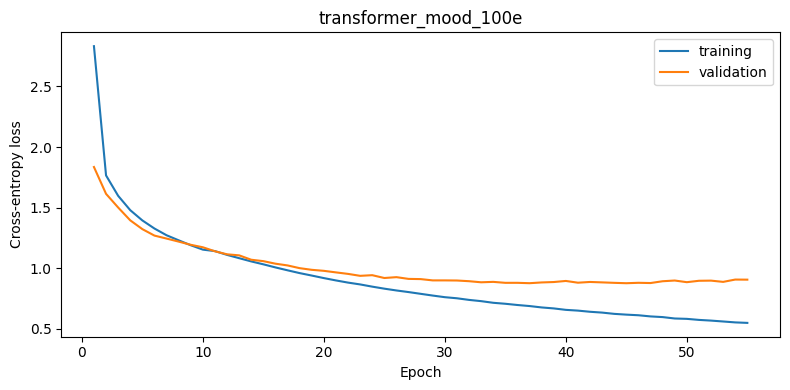

In [43]:
mood_run = train_or_load_experiment(
    "transformer_mood_100e",
    force_retrain=False,
    train_if_incomplete=True,
)


## 18. Architecture summary

The model has learned token and positional embeddings, four pre-normalized Transformer layers and a tied output projection. The architecture report is saved alongside the checkpoint.


In [44]:
show_active_model_architecture()


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
CausalTransformerLanguageModel                [1, 512]                  [1, 512, 599]             --                        True
├─Embedding: 1-1                              [1, 512]                  [1, 512, 192]             115,008                   True
├─Embedding: 1-2                              [1, 512]                  [1, 512, 192]             98,304                    True
├─Dropout: 1-3                                [1, 512, 192]             [1, 512, 192]             --                        --
├─TransformerEncoder: 1-4                     [1, 512, 192]             [1, 512, 192]             --                        True
│    └─ModuleList: 2-1                        --                        --                        --                        True
│    │    └─TransformerEncoderLayer: 3-1      [1, 512, 192]             [1, 512, 192]         

## 19. No-mood ablation

The ablation removes the mood token but keeps all other settings unchanged. This is the key control for determining whether differences in generation are actually caused by mood conditioning.


Tokenizing train:   0%|          | 0/1620 [00:00<?, ?it/s]

Tokenizing validation:   0%|          | 0/180 [00:00<?, ?it/s]

Tokenizing test:   0%|          | 0/324 [00:00<?, ?it/s]

Activated transformer_no_mood_100e | mood=False | vocabulary=592 | parameters=1,991,808


  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 043 | train=0.6267 | validation=0.8777 | ppl=2.41 | accuracy=0.726
Early stopping.


  0%|          | 0/39 [00:00<?, ?it/s]

,run_name,mood_conditioned,mood_token_repetitions,completed_epochs,test_loss,test_perplexity,test_token_accuracy,checkpoint
0,transformer_no_mood_100e,False,1,43,1.0186,2.7693,0.6958,/content/artifacts/experiments/transformer_no_...


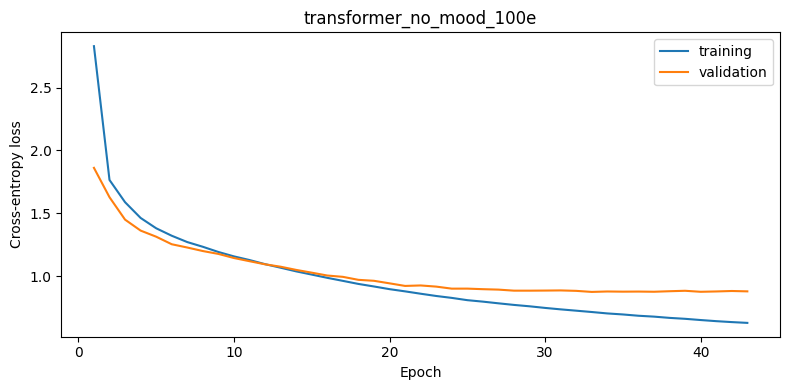

In [45]:
no_mood_run = train_or_load_experiment(
    "transformer_no_mood_100e",
    force_retrain=False,
    train_if_incomplete=True,
)


## 20. Mood-emphasis fine-tuning

The optional third experiment starts from the best mood-conditioned checkpoint. It repeats the mood token three times in the prefix and fine-tunes for at most 20 epochs with a smaller learning rate (`1e-4`). The architecture is unchanged.


Tokenizing train:   0%|          | 0/1620 [00:00<?, ?it/s]

Tokenizing validation:   0%|          | 0/180 [00:00<?, ?it/s]

Tokenizing test:   0%|          | 0/324 [00:00<?, ?it/s]

Activated transformer_mood_emphasis_ft20 | mood=True | vocabulary=599 | parameters=1,993,152
Initialized from: /content/artifacts/experiments/transformer_mood_100e/best_model.pt


  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 020 | train=0.5601 | validation=0.8716 | ppl=2.39 | accuracy=0.731


  0%|          | 0/39 [00:00<?, ?it/s]

,run_name,mood_conditioned,mood_token_repetitions,completed_epochs,test_loss,test_perplexity,test_token_accuracy,checkpoint
0,transformer_mood_emphasis_ft20,True,3,20,1.0475,2.8506,0.7014,/content/artifacts/experiments/transformer_moo...


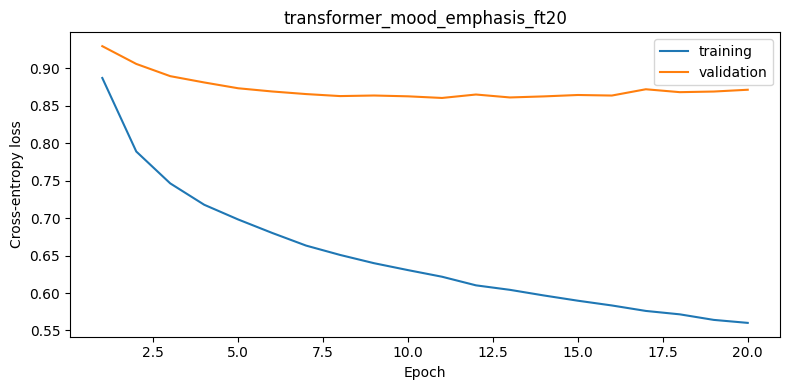

In [46]:
if RUN_OPTIONAL_MOOD_FINE_TUNING:
    emphasis_run = train_or_load_experiment(
        "transformer_mood_emphasis_ft20",
        force_retrain=False,
        train_if_incomplete=True,
    )
else:
    emphasis_run = None
    print("Mood-emphasis fine-tuning was skipped.")


# Part B — Controlled generation and evaluation

The evaluation fixes genre, track role, instrument and length, then changes only the requested mood. Ten samples are generated for each of the six labels. For a fixed sample index, the same random seed is reused across labels and experiments.

This paired protocol separates the effect of the condition token from random sampling variation.


## 21. MIDI feature extraction

The evaluation extracts tempo, note density, velocity, pitch, duration, melodic interval, polyphony and pitch-class entropy. Key mode is estimated from a duration- and velocity-weighted pitch-class profile.


In [47]:
MAJOR_PROFILE = np.array(
    [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
)
MINOR_PROFILE = np.array(
    [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]
)
PITCH_CLASS_NAMES = [
    "C", "C#", "D", "D#", "E", "F",
    "F#", "G", "G#", "A", "A#", "B",
]


def estimate_key_mode(notes):
    histogram = np.zeros(12, dtype=float)

    for note in notes:
        histogram[note.pitch % 12] += (
            max(note.end - note.start, 1e-3)
            * note.velocity
        )

    if histogram.sum() == 0:
        return "unknown", "unknown"

    histogram /= histogram.sum()
    candidates = []

    for tonic in range(12):
        candidates.append(
            (
                np.corrcoef(
                    histogram,
                    np.roll(MAJOR_PROFILE, tonic),
                )[0, 1],
                tonic,
                "major",
            )
        )
        candidates.append(
            (
                np.corrcoef(
                    histogram,
                    np.roll(MINOR_PROFILE, tonic),
                )[0, 1],
                tonic,
                "minor",
            )
        )

    _, tonic, mode = max(candidates, key=lambda item: item[0])
    return f"{PITCH_CLASS_NAMES[tonic]} {mode}", mode


def pitch_class_entropy(notes):
    counts = np.zeros(12, dtype=float)

    for note in notes:
        counts[note.pitch % 12] += 1

    probabilities = counts[counts > 0] / max(counts.sum(), 1)

    if not len(probabilities):
        return 0.0

    return float(-(probabilities * np.log2(probabilities)).sum())


def polyphony_rate(midi, fs=20):
    roll = midi.get_piano_roll(fs=fs)

    if roll.shape[1] == 0:
        return 0.0

    active_notes = (roll > 0).sum(axis=0)
    active_frames = active_notes > 0

    if not active_frames.any():
        return 0.0

    return float((active_notes[active_frames] > 1).mean())


In [48]:
FEATURE_COLUMNS = [
    "tempo_bpm",
    "note_density",
    "mean_velocity",
    "velocity_std",
    "mean_pitch",
    "pitch_std",
    "pitch_range",
    "mean_note_duration",
    "mean_absolute_interval",
    "polyphony_rate",
    "pitch_class_entropy",
]


def extract_midi_features(midi_path):
    midi = pretty_midi.PrettyMIDI(str(midi_path))

    notes = [
        note
        for instrument in midi.instruments
        if not instrument.is_drum
        for note in instrument.notes
    ]

    if not notes:
        return None

    notes_by_onset = sorted(
        notes,
        key=lambda note: (note.start, note.pitch, note.end),
    )

    duration = max(midi.get_end_time(), 1e-6)
    pitches = np.array([note.pitch for note in notes])
    velocities = np.array([note.velocity for note in notes])
    note_durations = np.array(
        [note.end - note.start for note in notes]
    )
    ordered_pitches = np.array(
        [note.pitch for note in notes_by_onset]
    )
    intervals = (
        np.abs(np.diff(ordered_pitches))
        if len(ordered_pitches) > 1
        else np.array([0.0])
    )

    _, tempos = midi.get_tempo_changes()
    tempo = float(tempos[0]) if len(tempos) else np.nan
    estimated_key, estimated_mode = estimate_key_mode(notes)

    return {
        "midi_path": str(midi_path),
        "duration_seconds": duration,
        "tempo_bpm": tempo,
        "note_count": len(notes),
        "note_density": len(notes) / duration,
        "mean_velocity": float(velocities.mean()),
        "velocity_std": float(velocities.std()),
        "mean_pitch": float(pitches.mean()),
        "pitch_std": float(pitches.std()),
        "pitch_range": int(pitches.max() - pitches.min()),
        "mean_note_duration": float(note_durations.mean()),
        "mean_absolute_interval": float(intervals.mean()),
        "polyphony_rate": polyphony_rate(midi),
        "pitch_class_entropy": pitch_class_entropy(notes),
        "estimated_key": estimated_key,
        "estimated_mode": estimated_mode,
    }


def generated_heuristic_mood(features):
    normalized_bpm = float(
        minmax_with_reference(
            pd.Series([features["tempo_bpm"]]),
            mood_parameters["bpm_min"],
            mood_parameters["bpm_max"],
        ).iloc[0]
    )
    normalized_velocity = float(
        minmax_with_reference(
            pd.Series([features["mean_velocity"]]),
            mood_parameters["velocity_min"],
            mood_parameters["velocity_max"],
        ).iloc[0]
    )

    arousal = (
        cfg["mood"]["arousal_bpm_weight"] * normalized_bpm
        + cfg["mood"]["arousal_velocity_weight"] * normalized_velocity
    )

    return (
        assign_mood(
            features["estimated_mode"],
            arousal,
            mood_parameters,
        ),
        arousal,
    )


## 22. Controlled evaluation functions

The originality analysis checks exact token-sequence matches and maximum Jaccard similarity between generated and training 8-token n-gram sets. Eta squared quantifies feature separation across requested mood labels.


In [49]:
def build_controlled_request(evaluation_label):
    request = dict(cfg["evaluation"]["controlled_request"])

    if "mood" in active_condition_fields:
        request["mood"] = evaluation_label

    return request


def music_only_ids(sequence_ids):
    return tuple(
        int(token_id)
        for token_id in sequence_ids
        if (
            0 <= int(token_id) < base_vocab_size
            and int(token_id) not in base_special_ids
        )
    )


def token_ngrams(sequence, n):
    sequence = tuple(sequence)

    if len(sequence) < n:
        return {sequence}

    return {
        sequence[index : index + n]
        for index in range(len(sequence) - n + 1)
    }


def build_originality_index():
    exact_lookup = {}
    ngram_cache = []
    n = cfg["evaluation"]["ngram_size"]

    for record in train_records:
        sequence = music_only_ids(record["ids"])
        exact_lookup.setdefault(sequence, record["id"])
        ngram_cache.append(
            {
                "id": record["id"],
                "ngrams": token_ngrams(sequence, n),
            }
        )

    return exact_lookup, ngram_cache


def compare_generated_to_training(
    midi_path,
    exact_lookup,
    ngram_cache,
):
    sequence = tuple(encode_midi_file(midi_path))
    generated_ngrams = token_ngrams(
        sequence,
        cfg["evaluation"]["ngram_size"],
    )

    best_similarity = 0.0
    nearest_training_id = None

    for item in ngram_cache:
        union = generated_ngrams | item["ngrams"]
        similarity = (
            len(generated_ngrams & item["ngrams"])
            / max(len(union), 1)
        )

        if similarity > best_similarity:
            best_similarity = similarity
            nearest_training_id = item["id"]

    return {
        "exact_training_copy": sequence in exact_lookup,
        "nearest_training_id": nearest_training_id,
        "maximum_ngram_jaccard": best_similarity,
    }


In [50]:
def run_controlled_evaluation(run_name, regenerate=False):
    activate_trained_experiment(run_name)

    output_csv = experiment_dir / "generated_evaluation.csv"

    if output_csv.exists() and not regenerate:
        evaluation = pd.read_csv(output_csv)
        print("Loaded:", output_csv)
        return evaluation

    exact_lookup, ngram_cache = build_originality_index()
    rows = []

    for evaluation_label in cfg["mood"]["labels"]:
        for sample_index in range(
            1,
            cfg["evaluation"]["generated_samples_per_label"] + 1,
        ):
            generation_seed = cfg["seed"] + sample_index
            seed_everything(generation_seed)

            request = build_controlled_request(evaluation_label)

            try:
                result = generate_from_request(
                    request=request,
                    sample_index=sample_index,
                    output_tag=f"evaluation_{evaluation_label}",
                )
                features = extract_midi_features(result["output_path"])

                row = {
                    "run_name": run_name,
                    "mood_conditioned": (
                        cfg["conditioning"]["include_mood"]
                    ),
                    "evaluation_label": evaluation_label,
                    "sample_index": sample_index,
                    "generation_seed": generation_seed,
                    "conditions": json.dumps(result["conditions"]),
                    "midi_path": str(result["output_path"]),
                    "sequence_hash": result["sequence_hash"],
                    "token_error_ratio": result["token_error_ratio"],
                    "valid_nonempty_midi": features is not None,
                }

                if features is not None:
                    pseudo_mood, arousal = generated_heuristic_mood(
                        features
                    )
                    row.update(features)
                    row.update(
                        {
                            "generated_pseudo_mood": pseudo_mood,
                            "generated_heuristic_arousal": arousal,
                            "heuristic_label_agreement": (
                                pseudo_mood == evaluation_label
                            ),
                        }
                    )
                    row.update(
                        compare_generated_to_training(
                            result["output_path"],
                            exact_lookup,
                            ngram_cache,
                        )
                    )

                rows.append(row)

            except Exception as error:
                rows.append(
                    {
                        "run_name": run_name,
                        "mood_conditioned": (
                            cfg["conditioning"]["include_mood"]
                        ),
                        "evaluation_label": evaluation_label,
                        "sample_index": sample_index,
                        "generation_seed": generation_seed,
                        "valid_nonempty_midi": False,
                        "generation_error": str(error),
                    }
                )

    evaluation = pd.DataFrame(rows)
    evaluation.to_csv(output_csv, index=False)
    return evaluation


def summarize_evaluation(evaluation):
    valid = evaluation[
        evaluation["valid_nonempty_midi"] == True
    ].copy()

    sequence_counts = (
        valid.groupby("sample_index")["sequence_hash"].nunique()
        if not valid.empty
        else pd.Series(dtype=float)
    )

    return {
        "run_name": evaluation["run_name"].iloc[0],
        "mood_conditioned": bool(
            evaluation["mood_conditioned"].iloc[0]
        ),
        "generated_files": len(evaluation),
        "valid_midi_rate": float(
            evaluation["valid_nonempty_midi"].mean()
        ),
        "mean_token_error_ratio": float(
            valid["token_error_ratio"].mean()
        ),
        "heuristic_label_agreement": float(
            valid["heuristic_label_agreement"].mean()
        ),
        "exact_copy_rate": float(
            valid["exact_training_copy"].fillna(False).mean()
        ),
        "mean_ngram_jaccard": float(
            valid["maximum_ngram_jaccard"].mean()
        ),
        "sequence_change_rate_across_labels": float(
            (sequence_counts > 1).mean()
        ),
    }


def eta_squared(dataframe, group_column, value_column):
    subset = dataframe[[group_column, value_column]].dropna()

    if subset.empty:
        return np.nan

    overall_mean = subset[value_column].mean()
    total = ((subset[value_column] - overall_mean) ** 2).sum()

    if total <= 0:
        return 0.0

    between = sum(
        len(group)
        * (group[value_column].mean() - overall_mean) ** 2
        for _, group in subset.groupby(group_column)
    )
    return float(between / total)


## 23. Generate the controlled evaluation set

`REGENERATE_EVALUATION=False` reuses existing CSV files when available. If a CSV is missing, the evaluation is generated automatically.


In [ ]:
mood_evaluation = run_controlled_evaluation(
    "transformer_mood_100e",
    regenerate=REGENERATE_EVALUATION,
)

no_mood_evaluation = run_controlled_evaluation(
    "transformer_no_mood_100e",
    regenerate=REGENERATE_EVALUATION,
)

emphasis_checkpoint = (
    project_root
    / "experiments"
    / "transformer_mood_emphasis_ft20"
    / "best_model.pt"
)

if emphasis_checkpoint.exists():
    emphasis_evaluation = run_controlled_evaluation(
        "transformer_mood_emphasis_ft20",
        regenerate=REGENERATE_EVALUATION,
    )
else:
    emphasis_evaluation = None
    print("Mood-emphasis checkpoint not found; third-model evaluation skipped.")


Activated transformer_mood_100e | mood=True | vocabulary=599 | parameters=1,993,152
Loaded transformer_mood_100e from epoch 45
Activated transformer_no_mood_100e | mood=False | vocabulary=592 | parameters=1,991,808
Loaded transformer_no_mood_100e from epoch 33
Activated transformer_mood_emphasis_ft20 | mood=True | vocabulary=599 | parameters=1,993,152
Loaded transformer_mood_emphasis_ft20 from epoch 11


## 24. Three-model comparison

The following cell combines next-token metrics, generation validity, heuristic agreement, sequence sensitivity and originality. It also computes eta-squared feature separation across requested labels.


In [ ]:
def load_json(path):
    if not path.exists():
        return {}

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


evaluation_by_run = {
    "transformer_mood_100e": mood_evaluation,
    "transformer_no_mood_100e": no_mood_evaluation,
}

if emphasis_evaluation is not None:
    evaluation_by_run["transformer_mood_emphasis_ft20"] = emphasis_evaluation

comparison_rows = []
effect_rows = []
label_feature_tables = []
main_features = [
    "tempo_bpm",
    "mean_velocity",
    "note_density",
    "mean_pitch",
    "pitch_range",
    "mean_note_duration",
]

for run_name, evaluation in evaluation_by_run.items():
    run_dir = project_root / "experiments" / run_name
    history_path = run_dir / "training_history.csv"
    history = (
        pd.read_csv(history_path)
        if history_path.exists()
        else pd.DataFrame()
    )
    test_metrics = load_json(run_dir / "test_metrics.json")

    summary_row = summarize_evaluation(evaluation)
    summary_row.update(
        {
            "completed_epochs": (
                int(history["epoch"].max())
                if not history.empty
                else np.nan
            ),
            "best_validation_loss": (
                float(history["validation_loss"].min())
                if not history.empty
                else np.nan
            ),
            "test_loss": test_metrics.get("loss"),
            "test_perplexity": test_metrics.get("perplexity"),
            "test_token_accuracy": test_metrics.get("token_accuracy"),
        }
    )
    comparison_rows.append(summary_row)

    valid = evaluation[evaluation["valid_nonempty_midi"] == True]

    for feature in FEATURE_COLUMNS:
        if feature in valid.columns:
            effect_rows.append(
                {
                    "run_name": run_name,
                    "feature": feature,
                    "eta_squared": eta_squared(
                        valid,
                        "evaluation_label",
                        feature,
                    ),
                }
            )

    available_features = [
        feature for feature in main_features if feature in valid.columns
    ]
    label_table = (
        valid.groupby("evaluation_label")[available_features]
        .mean()
        .reset_index()
    )
    label_table.insert(0, "run_name", run_name)
    label_feature_tables.append(label_table)

three_model_summary = pd.DataFrame(comparison_rows)
three_model_feature_effects = pd.DataFrame(effect_rows)
three_model_effect_table = three_model_feature_effects.pivot(
    index="feature",
    columns="run_name",
    values="eta_squared",
)
label_feature_comparison = pd.concat(
    label_feature_tables,
    ignore_index=True,
)

print("THREE-MODEL SUMMARY")
display(three_model_summary.round(4))

print("FEATURE SEPARATION")
display(three_model_effect_table.round(4))

print("MEAN FEATURES BY REQUESTED MOOD")
display(label_feature_comparison.round(3))

comparison_dir.mkdir(parents=True, exist_ok=True)
three_model_summary.to_csv(
    comparison_dir / "three_model_summary.csv",
    index=False,
)
three_model_feature_effects.to_csv(
    comparison_dir / "three_model_feature_effects.csv",
    index=False,
)
label_feature_comparison.to_csv(
    comparison_dir / "three_model_label_features.csv",
    index=False,
)


## 25. Results from the completed project run

The two baseline models have nearly identical next-token prediction quality. The stronger evidence for conditioning comes from the paired generation protocol.

| Model | Best val. loss | Test loss | Test PPL | Token acc. | Valid MIDI | Heuristic agreement | Sequence change | Exact copies |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Mood baseline | 0.8664 | 1.0161 | 2.7625 | 0.7055 | 1.000 | 0.6167 | 1.000 | 0.000 |
| No-mood baseline | 0.8733 | 1.0186 | 2.7693 | 0.6958 | 1.000 | 0.1667 | 0.000 | 0.000 |
| Mood-emphasis fine-tuning | 0.8573 | 1.0240 | 2.7844 | 0.7037 | 1.000 | 0.6500 | 1.000 | 0.000 |

### Interpretation

- The no-mood model produces the same sequence for all six evaluation labels when the seed and remaining metadata are fixed. This is expected because the evaluation label is absent from its input.
- Both mood-conditioned variants change their generated sequence for every tested seed.
- Heuristic agreement rises from 16.67% in the no-mood baseline to 61.67% in the mood baseline and 65.00% after mood-emphasis fine-tuning.
- All generated files are valid, token-decoding errors remain negligible and no exact training copy is detected.
- The fine-tuning stage improves controllability but slightly worsens test loss and perplexity, suggesting a small trade-off between stronger conditioning and general next-token modelling.

![Training and validation loss](../figures/training_curves.png)


## 26. Feature separation across requested labels

Eta squared measures the fraction of feature variance associated with the requested mood label. Tempo is the most strongly separated feature, followed by mean velocity. This is consistent with the pseudo-label construction, where both quantities directly determine arousal.

Mood-emphasis fine-tuning increases separation for most analysed features, especially pitch-class entropy, note density, mean pitch and velocity.

![Feature separation across requested labels](../figures/feature_separation_three_models.png)

These values demonstrate symbolic controllability, but they are not independent evidence of perceived emotion because tempo and velocity are also used to define the labels.


## 27. Generated versus real MIDI features

The next analysis compares generated examples with a fixed sample from the real test split through standardized mean differences. This comparison is exploratory: generated files use one fixed request, while the reference set contains mixed instruments, track roles and metadata.


In [ ]:
def standardized_mean_difference(first, second):
    first = pd.Series(first).dropna()
    second = pd.Series(second).dropna()

    if len(first) < 2 or len(second) < 2:
        return np.nan

    pooled_variance = (first.var(ddof=1) + second.var(ddof=1)) / 2

    if pooled_variance <= 0:
        return 0.0

    return float(
        (first.mean() - second.mean())
        / math.sqrt(pooled_variance)
    )


real_features_path = analysis_dir / "real_test_features.csv"

if real_features_path.exists():
    real_features = pd.read_csv(real_features_path)
else:
    reference_source = test_df.sample(
        n=min(
            len(test_df),
            cfg["evaluation"]["max_real_reference_files"],
        ),
        random_state=cfg["seed"],
    )

    real_rows = []

    for _, row in tqdm(
        reference_source.iterrows(),
        total=len(reference_source),
        desc="Real MIDI features",
    ):
        features = extract_midi_features(row["midi_path"])

        if features is not None:
            features["reference_mood"] = row["mood"]
            real_rows.append(features)

    real_features = pd.DataFrame(real_rows)
    real_features.to_csv(real_features_path, index=False)


real_comparison_rows = []

for run_name, evaluation in {
    "transformer_mood_100e": mood_evaluation,
    "transformer_no_mood_100e": no_mood_evaluation,
}.items():
    valid = evaluation[
        evaluation["valid_nonempty_midi"] == True
    ]

    for feature in FEATURE_COLUMNS:
        if feature not in valid.columns:
            continue

        real_comparison_rows.append(
            {
                "run_name": run_name,
                "feature": feature,
                "generated_mean": valid[feature].mean(),
                "real_mean": real_features[feature].mean(),
                "standardized_mean_difference": (
                    standardized_mean_difference(
                        valid[feature],
                        real_features[feature],
                    )
                ),
            }
        )

real_generated_comparison = pd.DataFrame(real_comparison_rows)
display(real_generated_comparison.round(4))

real_generated_comparison.to_csv(
    comparison_dir / "real_generated_comparison.csv",
    index=False,
)


### Interpretation of the real-data comparison

The mood baseline matches the real mean velocity closely and has a relatively small tempo difference. Larger differences appear in pitch range, melodic interval size and polyphony. The generated samples tend to use wider pitch material, larger intervals, shorter notes and more simultaneous notes than the mixed reference set.

A stricter future evaluation should compare generated MIDI only with real examples matched on track role, instrument, number of measures and mood.


# Part C — Qualitative inspection and manual generation

Quantitative validity does not guarantee musical quality. The following cells support listening, piano-roll inspection and a small human-rating sheet. The project report does not claim perceptual mood accuracy because no completed listening study is included.


## 28. Controlled listening

Choose one available experiment and one paired sample index. The requested instrument is applied only to a rendered copy used for playback.


In [ ]:
LISTENING_EXPERIMENT = (
    "transformer_mood_emphasis_ft20"
    if emphasis_evaluation is not None
    else "transformer_mood_100e"
)
LISTENING_SAMPLE_INDEX = 2

listening_evaluation = evaluation_by_run[LISTENING_EXPERIMENT]
activate_trained_experiment(LISTENING_EXPERIMENT)

for label in cfg["mood"]["labels"]:
    matches = listening_evaluation[
        (listening_evaluation["evaluation_label"] == label)
        & (listening_evaluation["sample_index"] == LISTENING_SAMPLE_INDEX)
        & (listening_evaluation["valid_nonempty_midi"] == True)
    ]

    if matches.empty:
        print("No valid MIDI for:", label)
        continue

    row = matches.iloc[0]
    print(
        f"\nLabel={label} | "
        f"pseudo-mood={row.get('generated_pseudo_mood')} | "
        f"agreement={row.get('heuristic_label_agreement')} | "
        f"path={row['midi_path']}"
    )

    result_for_rendering = {
        "output_path": Path(row["midi_path"]),
        "request": dict(cfg["evaluation"]["controlled_request"]),
    }
    rendered_path = assign_requested_instrument(result_for_rendering)
    show_midi(rendered_path, show_piano_roll=False)


We can note from the audio above, that most of the agreement comes from danger and tension moods, which seem to be the most similar to how human perceive those two moods. Other labels are often interpretable and not so clear from a human perspective, so the model is not so good in recognizing the heuristic used.

## 29. Listening-test template

The CSV contains empty columns for perceived mood, mood match, musical coherence, pleasantness and free-form notes. It is a template for future human evaluation, not a completed experiment.


In [ ]:
listening_test = listening_evaluation[
    listening_evaluation["valid_nonempty_midi"] == True
][
    [
        "evaluation_label",
        "sample_index",
        "midi_path",
    ]
].copy()

listening_test["perceived_mood"] = ""
listening_test["mood_match_1_5"] = ""
listening_test["musical_coherence_1_5"] = ""
listening_test["pleasantness_1_5"] = ""
listening_test["notes"] = ""

listening_test_path = (
    project_root
    / "experiments"
    / "comparisons"
    / "listening_test.csv"
)

listening_test.to_csv(
    listening_test_path,
    index=False,
)

print("Listening-test sheet:", listening_test_path)


Listening-test sheet: /content/artifacts/experiments/comparisons/listening_test.csv


## 30. Manual metadata-conditioned generation

The request below can be edited using values observed in the training split. The active experiment is chosen explicitly before generation.


In [ ]:
MANUAL_EXPERIMENT = (
    "transformer_mood_emphasis_ft20"
    if emphasis_checkpoint.exists()
    else "transformer_mood_100e"
)
activate_trained_experiment(MANUAL_EXPERIMENT)

request = {
    "mood": "joy",
    "genre": "cinematic",
    "track_role": "main_melody",
    "inst": "acoustic_piano",
    "num_measures": 8,
}

manual_result = generate_and_listen(request)


To inspect valid values for one conditioning field, change `FIELD` and execute the next cell.


In [ ]:
FIELD = "inst"

available_values = sorted(
    train_df[FIELD].dropna().unique(),
    key=str,
)

print(f"{FIELD}: {len(available_values)} values")
print(available_values)


inst: 77 values
['acoustic_guitar', 'acoustic_piano', 'acoustic_piano-3', 'bassoon', 'brass_ensemble', 'brass_ensemble-2', 'celesta', 'choir', 'clarinet', 'clarinet-2', 'electric_guitar_clean', 'electric_guitar_clean-2', 'electric_guitar_clean-5', 'electric_guitar_distortion', 'electric_guitar_distortion-2', 'electric_guitar_distortion-3', 'electric_guitar_distortion-4', 'flute', 'flute-2', 'glockenspiel', 'harp', 'harp-2', 'harp-4', 'horn', 'horn-3', 'horn-4', 'marimba', 'nylon_guitar', 'nylon_guitar-2', 'nylon_guitar-3', 'oboe', 'orgel', 'string_cello', 'string_cello-2', 'string_cello-3', 'string_cello-4', 'string_cello-5', 'string_double_bass', 'string_double_bass-2', 'string_double_bass-3', 'string_double_bass-4', 'string_ensemble', 'string_ensemble-2', 'string_ensemble-5', 'string_viola-2', 'string_violin', 'string_violin-2', 'synth_bass', 'synth_bass-2', 'synth_bass-5', 'synth_bass-6', 'synth_bass_wobble', 'synth_pad', 'synth_pad-10', 'synth_pad-12', 'synth_pad-2', 'synth_pad-3',

## 31. Narrative-to-mood demonstration

This interface uses keyword matching rather than a trained NLP model. It is included only to illustrate how a future scene-understanding component could pass a mood label to the MIDI generator.


In [ ]:
MOOD_KEYWORDS = {
    "calm": ["calm", "peaceful", "quiet", "safe", "serene", "calmo"],
    "joy": ["joy", "happy", "victory", "celebration", "felice"],
    "sadness": ["sad", "loss", "grief", "lonely", "triste"],
    "mystery": ["mystery", "unknown", "ancient", "hidden", "mistero"],
    "tension": ["tension", "suspense", "uncertain", "anxious"],
    "danger": ["danger", "attack", "battle", "enemy", "threat"],
}


def keyword_mood_classifier(text):
    text = text.lower()
    scores = {
        mood: sum(keyword in text for keyword in keywords)
        for mood, keywords in MOOD_KEYWORDS.items()
    }

    if max(scores.values()) == 0:
        return "mystery"

    return max(scores, key=scores.get)


def generate_from_narrative(text, instrument="string_ensemble"):
    if "mood" not in active_condition_fields:
        raise RuntimeError(
            "Load a mood-conditioned experiment first."
        )

    mood = keyword_mood_classifier(text)

    return generate_and_listen(
        {
            "mood": mood,
            "genre": "cinematic",
            "track_role": "main_melody",
            "inst": instrument,
            "num_measures": 8,
        }
    )


scene_text = """
The hero enters an abandoned castle.
The corridors are silent, but something moves behind the walls.
"""

narrative_result = generate_from_narrative(scene_text)


## 32. Saved artifacts

Each experiment directory contains configuration files, model summaries, checkpoints, training history, test metrics, generated MIDI files and evaluation CSV files. Cross-experiment tables are saved under `artifacts/experiments/comparisons/`.

Large artifacts are intentionally ignored by Git. The repository keeps only compact exported result tables and figures needed to document the completed run.


In [ ]:
freeze_path = project_root / "pip_freeze.txt"

with open(freeze_path, "w", encoding="utf-8") as file:
    subprocess.run(
        ["pip", "freeze"],
        stdout=file,
        text=True,
        check=False,
    )

print("Project root:", project_root)
print("Comparison directory:", comparison_dir)
print("Environment:", freeze_path)


## 33. Limitations and future work

1. **Pseudo-label circularity.** Requested mood and automatic agreement are both derived from mode, tempo and velocity. Agreement therefore measures consistency with the heuristic, not human perception.
2. **Single-track generation.** Each output is one musical part, not a coordinated soundtrack arrangement.
3. **Instrument post-processing.** The requested General MIDI program is enforced only in a listening copy; this does not prove learned timbral control.
4. **Restricted musical domain.** Training uses cinematic, standard-rhythm, 4/4 examples of four or eight measures.
5. **No formal listening study.** A rating sheet is prepared, but no completed listener data is reported.
6. **Simplified text interface.** Narrative conditioning is keyword-based and is not a trained NLP component.

The most important next step is a human listening evaluation. Other extensions include explicit mood embeddings, an auxiliary mood-classification loss, matched real-data comparisons, coordinated multi-track generation and a trained scene-to-mood model.

## References

1. H. Lee et al., “ComMU: Dataset for Combinatorial Music Generation,” *NeurIPS*, 2022.
2. Y.-S. Huang and Y.-H. Yang, “Pop Music Transformer: Beat-based Modeling and Generation of Expressive Pop Piano Compositions,” *ACM Multimedia*, 2020.
3. N. Fradet et al., “MidiTok: A Python Package for MIDI File Tokenization,” arXiv:2310.17202, 2023.
4. A. Vaswani et al., “Attention Is All You Need,” *NeurIPS*, 2017.
5. A. Paszke et al., “PyTorch: An Imperative Style, High-Performance Deep Learning Library,” *NeurIPS*, 2019.

ComMU is distributed for non-commercial research under CC BY-NC-SA 4.0. Check the official dataset repository before redistributing data or trained artifacts.
